# EJERCICIO : COMPARAR MODELOS DE REGRESION PARA ESTE DATASET
## DATASET [kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance/data)

In [ ]:
DATASET_URL = 'https://github.com/stedy/Machine-Learning-with-R-datasets/raw/refs/heads/master/insurance.csv'

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sns.set(style='whitegrid',context='notebook')

# PASO 2 CARGAMOS EL DATASET

In [ ]:
df = pd.read_csv(DATASET_URL)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


 # PASO 3 : EDA

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [ ]:
df_cleaned = remove_outliers(df,'bmi')
df_cleaned = remove_outliers(df_cleaned,'age')
df_cleaned = remove_outliers(df_cleaned,'charges')
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# PASO 4: CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

In [ ]:
categorical_columns = df_cleaned.select_dtypes(object).columns
categorical_columns

Index(['sex', 'smoker', 'region'], dtype='object')

In [ ]:
for cc in categorical_columns:
  print("*"*50)
  print(df[cc].value_counts())

**************************************************
sex
male      676
female    662
Name: count, dtype: int64
**************************************************
smoker
no     1064
yes     274
Name: count, dtype: int64
**************************************************
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [ ]:
ordinal_cols = ['sex','smoker']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['sex', 'smoker'] ['region']


In [ ]:
import sklearn.compose
import sklearn.preprocessing

In [ ]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['sex', 'smoker']),
                                ('onehotencoder', OneHotEncoder(), ['region'])])

In [ ]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df_cleaned),
        columns = transformer.get_feature_names_out(),
        index=df_cleaned.index
    )
)
data_transformed_df

,ordinalencoder__sex,ordinalencoder__smoker,onehotencoder__region_northeast,onehotencoder__region_northwest,onehotencoder__region_southeast,onehotencoder__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__charges
0,0.0,1.0,0.0,0.0,0.0,1.0,19.0,27.900,0.0,16884.92400
1,1.0,0.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,1725.55230
2,1.0,0.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,4449.46200
3,1.0,0.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,21984.47061
4,1.0,0.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,3866.85520
...,...,...,...,...,...,...,...,...,...,...
1333,1.0,0.0,0.0,1.0,0.0,0.0,50.0,30.970,3.0,10600.54830
1334,0.0,0.0,1.0,0.0,0.0,0.0,18.0,31.920,0.0,2205.98080
1335,0.0,0.0,0.0,0.0,1.0,0.0,18.0,36.850,0.0,1629.83350
1336,0.0,0.0,0.0,0.0,0.0,1.0,21.0,25.800,0.0,2007.94500


In [ ]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,sex,smoker,region_northeast,region_northwest,region_southeast,region_southwest,age,bmi,children,charges
0,0.0,1.0,0.0,0.0,0.0,1.0,19.0,27.900,0.0,16884.92400
1,1.0,0.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,1725.55230
2,1.0,0.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,4449.46200
3,1.0,0.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,21984.47061
4,1.0,0.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,3866.85520
...,...,...,...,...,...,...,...,...,...,...
1333,1.0,0.0,0.0,1.0,0.0,0.0,50.0,30.970,3.0,10600.54830
1334,0.0,0.0,1.0,0.0,0.0,0.0,18.0,31.920,0.0,2205.98080
1335,0.0,0.0,0.0,0.0,1.0,0.0,18.0,36.850,0.0,1629.83350
1336,0.0,0.0,0.0,0.0,0.0,1.0,21.0,25.800,0.0,2007.94500


In [ ]:
data_transformed_df.dtypes

,0
sex,float64
smoker,float64
region_northeast,float64
region_northwest,float64
region_southeast,float64
region_southwest,float64
age,float64
bmi,float64
children,float64
charges,float64


In [ ]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['charges']
corr_charges.sort_values(ascending=False)

,charges
charges,1.000000
smoker,0.596213
age,0.448798
children,0.089083
region_northeast,0.067055
region_northwest,0.037770
sex,-0.022893
region_southeast,-0.029093
bmi,-0.064483
region_southwest,-0.076394


<Axes: >

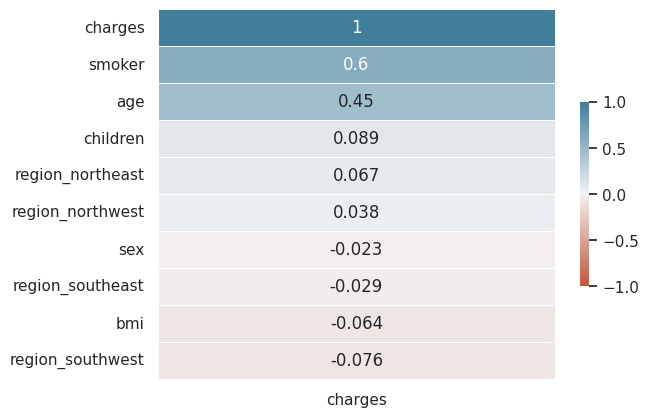

In [ ]:
sns.heatmap(
    data=corr_charges.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [ ]:
cols = corr_charges.index.tolist()
cols.remove('charges')
cols

['sex',
 'smoker',
 'region_northeast',
 'region_northwest',
 'region_southeast',
 'region_southwest',
 'age',
 'bmi',
 'children']

In [ ]:
X = data_transformed_df[cols].values
y = data_transformed_df['charges'].values.reshape(-1,1)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=0.1),
    "Ridge": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel='linear'),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

In [ ]:
results = {}
for name,model in models.items():
  model.fit(X_train_scaled,y_train_scaled.ravel())
  y_pred_scaled = model.predict(X_test_scaled)

  r2 = r2_score(y_test_scaled,y_pred_scaled)
  mse = mean_squared_error(y_test_scaled,y_pred_scaled)
  mae = mean_absolute_error(y_test_scaled,y_pred_scaled)
  results[name] = {"R2":r2,"MSE":mse,"MAE":mae}

In [ ]:
results_df = pd.DataFrame(results).T
results_df

,R2,MSE,MAE
Linear Regression,0.632814,0.390778,0.367483
Lasso,0.596882,0.429018,0.408205
Ridge,0.632883,0.390704,0.367459
KNN Regressor,0.593727,0.432376,0.395894
SVR,0.613769,0.411046,0.273901
Random Forest Regressor,0.643084,0.379847,0.339100


In [ ]:
best_r2_model = results_df['R2'].idxmax()
best_mse_model = results_df['MSE'].idxmin()
print(f"\nBest model based on R2: {best_r2_model} (R2: {results_df.loc[best_r2_model, 'R2']:.4f})")
print(f"Best model based on MSE: {best_mse_model} (MSE: {results_df.loc[best_mse_model, 'MSE']:.2f})")


Best model based on R2: Random Forest Regressor (R2: 0.6431)
Best model based on MSE: Random Forest Regressor (MSE: 0.38)


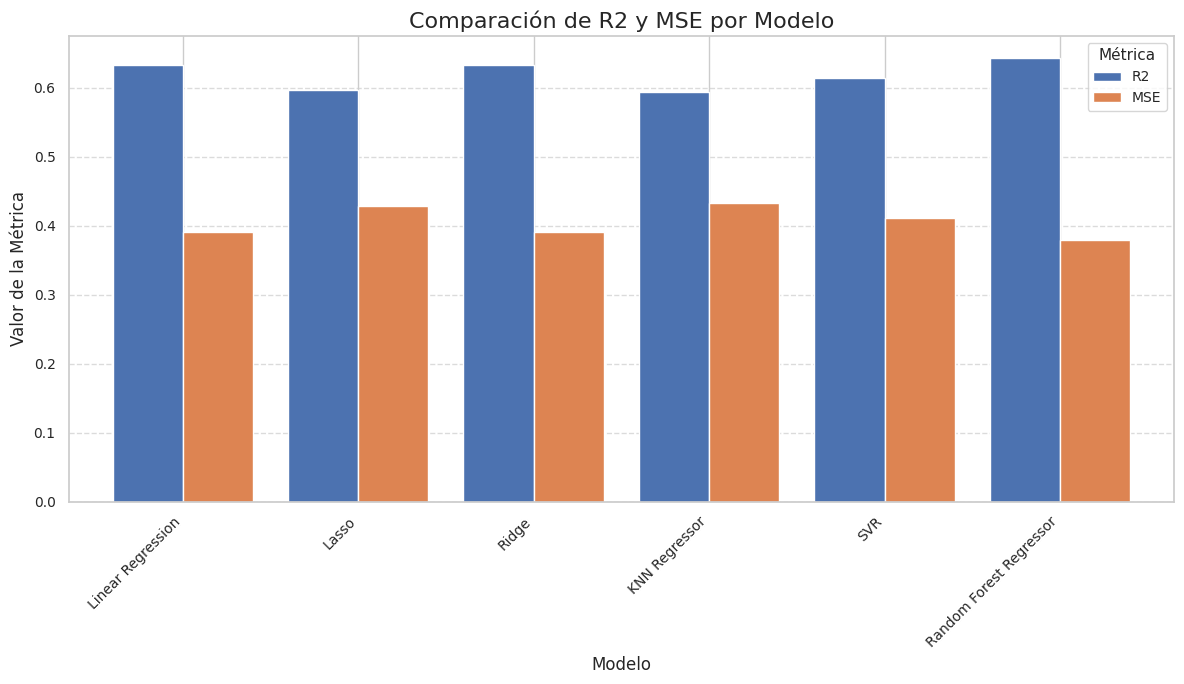

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las métricas R2 y MSE para comparar
results_to_plot = results_df[['R2', 'MSE']]

# Crear el gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 7))
results_to_plot.plot(kind='bar', ax=ax, width=0.8)

plt.title('Comparación de R2 y MSE por Modelo', fontsize=16)
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métrica', fontsize=10, title_fontsize='11')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Get the best model name from the previous results
best_model_name = results_df['R2'].idxmax()
best_model = models[best_model_name]

# Save the best model
joblib.dump(best_model, 'model.pkl')
print(f"Modelo '{best_model_name}' guardado como 'best_regression_model.pkl'")

# Save the X scaler
joblib.dump(scaler_X, 'scaler_X.pkl')
print("Scaler para X guardado como 'scaler_X.pkl'")

# Save the y scaler
joblib.dump(scaler_y, 'scaler_y.pkl')
print("Scaler para y guardado como 'scaler_y.pkl'")

Modelo 'Random Forest Regressor' guardado como 'best_regression_model.pkl'
Scaler para X guardado como 'scaler_X.pkl'
Scaler para y guardado como 'scaler_y.pkl'


In [ ]:
import joblib
import numpy as np
import pandas as pd

# Cargar el modelo y los scalers
loaded_model = joblib.load('model.pkl')
loaded_scaler_X = joblib.load('scaler_X.pkl')
loaded_scaler_y = joblib.load('scaler_y.pkl')

# Las columnas de entrada en el orden correcto (sin 'charges')
feature_cols = ['sex', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest', 'age', 'bmi', 'children']

def predict_price(
    sex: float,
    smoker: float,
    region_northeast: float,
    region_northwest: float,
    region_southeast: float,
    region_southwest: float,
    age: float,
    bmi: float,
    children: float
) -> float:
    """
    Predice el costo del seguro basado en las características proporcionadas.

    Args:
        sex (float): 0.0 para femenino, 1.0 para masculino.
        smoker (float): 0.0 para no fumador, 1.0 para fumador.
        region_northeast (float): 1.0 si es noreste, 0.0 en otro caso.
        region_northwest (float): 1.0 si es noroeste, 0.0 en otro caso.
        region_southeast (float): 1.0 si es sureste, 0.0 en otro caso.
        region_southwest (float): 1.0 si es suroeste, 0.0 en otro caso.
        age (float): Edad del asegurado.
        bmi (float): Índice de Masa Corporal del asegurado.
        children (float): Número de hijos a cargo del asegurado.

    Returns:
        float: El costo predicho del seguro.
    """
    # Crear un array con los valores de entrada en el orden correcto
    input_data = np.array([
        sex,
        smoker,
        region_northeast,
        region_northwest,
        region_southeast,
        region_southwest,
        age,
        bmi,
        children
    ]).reshape(1, -1)

    # Escalar las características de entrada usando el scaler_X cargado
    input_scaled = loaded_scaler_X.transform(input_data)

    # Realizar la predicción con el modelo cargado
    predicted_charge_scaled = loaded_model.predict(input_scaled)

    # Invertir la escala de la predicción usando el scaler_y cargado
    predicted_charge = loaded_scaler_y.inverse_transform(predicted_charge_scaled.reshape(-1, 1))

    return predicted_charge[0][0]

# Ejemplo de uso de la función:
# Asumiendo un hombre, no fumador, en el suroeste, de 30 años, con BMI de 25 y 1 hijo.
# sex=1.0 (male), smoker=0.0 (no), region_northeast=0.0, region_northwest=0.0,
# region_southeast=0.0, region_southwest=1.0, age=30.0, bmi=25.0, children=1.0

sample_prediction = predict_price(1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 30.0, 25.0, 1.0)
print(f"El costo de seguro predicho para el ejemplo es: ${sample_prediction:.2f}")

# Otro ejemplo: mujer, fumadora, noreste, 45 años, BMI 30, 2 hijos
sample_prediction_2 = predict_price(0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 45.0, 30.0, 2.0)
print(f"El costo de seguro predicho para el segundo ejemplo es: ${sample_prediction_2:.2f}")

El costo de seguro predicho para el ejemplo es: $5079.86
El costo de seguro predicho para el segundo ejemplo es: $25019.64
